# Audio end-of-turn detection in office noise
### Whisper-tiny + LoRA, trained three ways, served behind a FastAPI endpoint

**The problem.** A voice agent has to decide, every time the caller pauses, whether the caller has **finished** (reply now) or is only **pausing** (keep listening). Interrupting someone is the costly mistake; replying a little late is only slow. Background office noise makes the call harder.

**The question.** Does training on office noise, or cleaning the audio first with WebRTC noise suppression, keep an audio end-of-turn model reliable? And how does it compare with Pipecat's open **Smart Turn v3.2**?

**The experiment.** One recipe, three training sets, tested on an office noise none of the models ever heard:

| Model | Trained on |
|---|---|
| **A** | Pipecat's English speech as is ("native") |
| **B** | the same speech + office noise (`it-office-3`) |
| **C** | B's audio after WebRTC noise suppression |

**Headline results**
- **B is the most robust.** On the unseen office noise at 0 dB it answers 73% of turn ends quickly (Smart Turn: 62%) and interrupts half as often (9.9% vs 20.3%), at no cost on clean audio.
- **Noise suppression (C) adds nothing over B.** Train on noise; skip the extra step.
- **Serving:** 20.8 ms per request, about 120 requests/s at p99 under 100 ms on an M5 laptop. Docker image: 511 MB, identical outputs.

**Contents:** 1. Setup · 2. Data · 3. Office noise and noise suppression · 4. Model · 5. Training · 6. Evaluation · 7. Serving · 8. Live API tests · 9. Load testing · 10. Conclusions

## 1. Setup

Run the notebook from the project folder with the `.venv (Python 3.12)` kernel. The live API tests (section 8) need the server running in a terminal:

```bash
cd ~/Desktop/Happyrobot\ 2
EOT_MAX_INFLIGHT=8 .venv/bin/uvicorn service.app:app --port 8000      # the API
docker run --rm -d -p 8001:8000 --cpus 4 -e EOT_MAX_INFLIGHT=4 eot-audio  # optional: the same API in Docker
```

In [1]:
import asyncio, inspect, io, json, logging, os, sys, time, warnings, wave
from pathlib import Path

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
os.environ.update(TRANSFORMERS_VERBOSITY="error", HF_HUB_DISABLE_PROGRESS_BARS="1", TQDM_DISABLE="1",
                  HF_HUB_OFFLINE="1")  # whisper-tiny is already cached locally

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import Audio, Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator, PercentFormatter

ROOT = Path.cwd() if (Path.cwd() / "eot_lora").exists() else Path.home() / "Desktop" / "Happyrobot 2"
os.chdir(ROOT)
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

from eot_lora import audio as A                     # decoding, noise overlay, WebRTC noise suppression
from eot_lora.serving import AudioEoTPredictor, log_mel, pcm16_to_float, read_wav   # torch-free inference
from client import load_clips, to_wav               # the inference/test script

SR = 16_000
API, DOCKER_API = "http://localhost:8000", "http://localhost:8001"
MEL = np.load(ROOT / "runs" / "B" / "mel_filters.npy")

# Chart style: reference palette on a light surface, thin marks, hairline grid, text in ink (never series color)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
MODELS = ["A", "B", "C", "ST"]
COLOR = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a", "ST": "#eda100"}
MARKER = {"A": "o", "B": "s", "C": "^", "ST": "D"}
NAME = {"A": "A: native audio", "B": "B: + office noise", "C": "C: + office noise, then NS", "ST": "Smart Turn v3.2"}
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 1, "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 1, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlelocation": "left",
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "legend.frameon": False, "figure.dpi": 110, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
})

def line(ax, x, y, key, label, color):
    """2px line, 8px markers with a 2px surface ring."""
    ax.plot(x, y, color=color, marker=MARKER.get(key, "o"), lw=2, ms=8, mec=SURFACE, mew=2, label=label)

def spectrogram(ax, x, title, vmin=None, vmax=None):
    ax.imshow(log_mel(x, MEL), origin="lower", aspect="auto", cmap=BLUES, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.grid(False)
    ax.set_xticks([0, 200, 400, 600, 800], ["0", "2", "4", "6", "8 s"])
    ax.set_yticks([])

def api_up(url):
    try:
        return httpx.get(f"{url}/health", timeout=2).json()
    except Exception:
        return None

for name, url in [("API (bare metal)", API), ("API (Docker)", DOCKER_API)]:
    h = api_up(url)
    print(f"{name:17s} {url}: " + (f"up · model {h['condition']} · threshold {h['threshold']:.3f} · "
                                   f"{h['max_inflight_per_worker']} inferences in flight" if h else "not running"))

API (bare metal)  http://localhost:8000: up · model B · threshold 0.774 · 8 inferences in flight
API (Docker)      http://localhost:8001: up · model B · threshold 0.774 · 4 inferences in flight


## 2. Data

**Source:** Pipecat's open [Smart Turn v3.2 dataset](https://huggingface.co/datasets/pipecat-ai/smart-turn-data-v3.2-train): 270,946 training and 31,527 test clips in 23 languages, each labelled *complete* (the speaker finished) or *incomplete* (a mid-turn pause). In the English part, about a third is synthetic speech (Google Chirp 3, Rime and Orpheus TTS) and two-thirds are human recordings. Pipecat already mixed some background noise into it.

**What we used:** the English clips only. Every shard mixes all languages, so all 93 shards (46 GB) were streamed and filtered (`eot_lora/download.py`). The training clips were split 90/10 into train/validation by a hash of the clip ID.

In [2]:
english = {s: sum(pq.ParquetFile(f).metadata.num_rows for f in (ROOT / "data" / "english" / s).glob("*.parquet"))
           for s in ("train", "test")}
rows = []
for set_name, label in [("train_A", "train"), ("val_A", "validation"), ("test_native", "test")]:
    m = pq.read_table(ROOT / "data" / "features" / f"{set_name}.meta.parquet",
                      columns=["endpoint_bool", "dataset", "synthetic"]).to_pandas()
    rows.append({"split": label, "clips": len(m), "complete (%)": round(100 * m.endpoint_bool.mean(), 1),
                 "synthetic (%)": round(100 * m.synthetic.fillna(False).astype(bool).mean(), 1),
                 "sources": m.dataset.nunique()})
print(f"English clips downloaded: {english['train']:,} train, {english['test']:,} test")
display(pd.DataFrame(rows).set_index("split"))

English clips downloaded: 65,802 train, 7,820 test


,clips,complete (%),synthetic (%),sources
split,,,,
train,59177,49.3,33.8,10
validation,6625,49.5,33.3,10
test,7820,49.0,31.4,10


**What the model sees.** Each prediction uses the last 8 seconds of the caller's turn: 16 kHz mono audio, zero-padded at the start if shorter, turned into an 80-band log-mel spectrogram (80 × 800 frames). Below is one clip of each label.

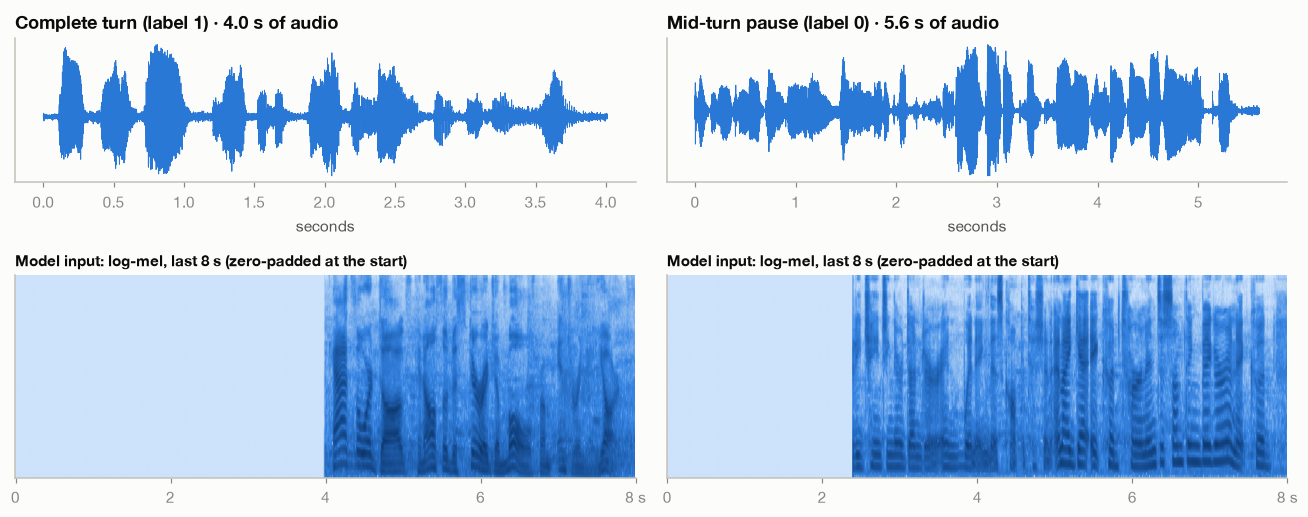

**Listen** — complete turn:

mid-turn pause:

In [3]:
clips = load_clips("test_native", 60, seed=3)
dur = lambda c: len(c["pcm"]) / 2 / SR
complete = next(c for c in clips if c["endpoint_bool"] and 3 < dur(c) < 7)
midturn = next(c for c in clips if not c["endpoint_bool"] and 3 < dur(c) < 7)

fig, axes = plt.subplots(2, 2, figsize=(12, 4.8), gridspec_kw={"height_ratios": [1, 1.4]})
for col, (c, title) in enumerate([(complete, "Complete turn (label 1)"), (midturn, "Mid-turn pause (label 0)")]):
    x = pcm16_to_float(c["pcm"])
    axes[0, col].plot(np.arange(len(x)) / SR, x, color=COLOR["A"], lw=0.6)
    axes[0, col].set_title(f"{title} · {len(x) / SR:.1f} s of audio")
    axes[0, col].set_xlabel("seconds"); axes[0, col].set_yticks([])
    spectrogram(axes[1, col], x, "Model input: log-mel, last 8 s (zero-padded at the start)")
fig.tight_layout(); plt.show()

display(Markdown("**Listen** — complete turn:")); display(Audio(pcm16_to_float(complete["pcm"]), rate=SR, normalize=False))
display(Markdown("mid-turn pause:")); display(Audio(pcm16_to_float(midturn["pcm"]), rate=SR, normalize=False))

## 3. Office noise and noise suppression

Two recordings of an IT office (about 28 s each, not in Pipecat's noise library):
- **office-3** is mixed into the **training and validation** audio of models B and C,
- **office-5** is used **only at test time**, so the test measures generalization to a new noise.

How the noise is mixed (`eot_lora/audio.py`, `overlay`):
- **SNR is measured against the active speech**, not the whole clip. Otherwise complete turns (which end in silence) would get quieter noise than mid-turn clips and the label would leak.
- **80% of training clips** get noise at a random 5–20 dB, stratified by label and source; 20% stay clean.
- Noise level and offset are drawn **once per clip from a hash of its ID**, so B and C see exactly the same noise.
- The **test** set gets office-5 at fixed levels: 20, 10, 5 and 0 dB (0 dB = noise as loud as the speech, beyond anything in training).

office-3 (train): 28.6 s · office-5 (test only): 27.7 s


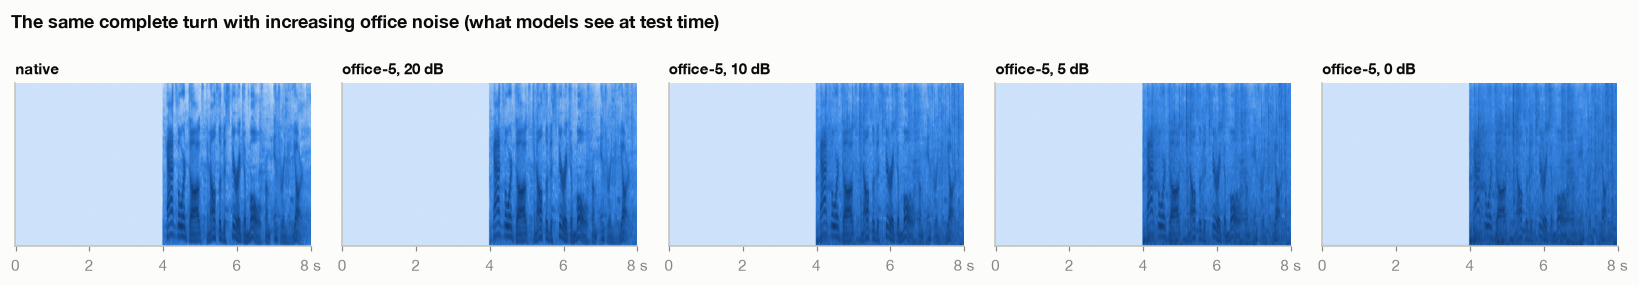

**native**

**office-5, 10 dB**

**office-5, 0 dB**

In [4]:
x = pcm16_to_float(complete["pcm"])
office3, office5 = A.noise("office3"), A.noise("office5")
print(f"office-3 (train): {len(office3) / SR:.1f} s · office-5 (test only): {len(office5) / SR:.1f} s")

versions = {"native": x}
for snr in (20, 10, 5, 0):
    versions[f"office-5, {snr} dB"] = A.overlay(x, office5, snr, offset=2 * SR)[1]

ref = log_mel(x, MEL)
fig, axes = plt.subplots(1, 5, figsize=(15, 2.6), sharey=True)
for ax, (label, v) in zip(axes, versions.items()):
    spectrogram(ax, v, label, vmin=ref.min(), vmax=ref.max())
fig.suptitle("The same complete turn with increasing office noise (what models see at test time)", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

for label in ("native", "office-5, 10 dB", "office-5, 0 dB"):
    display(Markdown(f"**{label}**")); display(Audio(versions[label], rate=SR, normalize=False))

**Noise suppression (model C).** WebRTC's noise suppressor, through LiveKit's WebRTC audio processing module (`eot_lora/audio.py`, `webrtc_ns`):
- only noise suppression is on (no echo cancellation, gain control or high-pass filter);
- it processes 10 ms frames and is warmed up on 1 s of the preceding noise, as on a live call;
- its 96-sample (6 ms) delay is measured and compensated, so the end of the turn stays aligned.

WebRTC NS on office-5 noise alone: -38.9 dBFS -> -46.3 dBFS (7.4 dB removed)


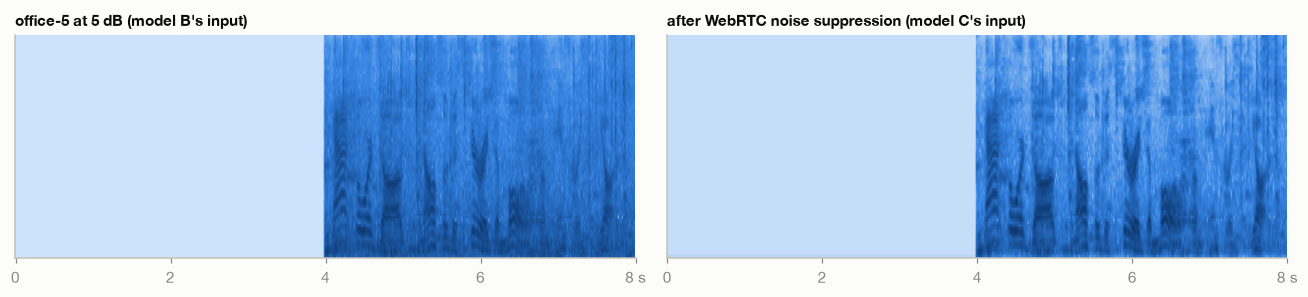

**before**

**after noise suppression**

In [5]:
pre, noisy = A.overlay(x, office5, 5, offset=2 * SR)
cleaned = A.webrtc_ns(noisy, pre=pre)

noise_only = office5[3 * SR: 5 * SR]
suppressed = A.webrtc_ns(noise_only, pre=office5[2 * SR: 3 * SR])
db = lambda y: 10 * np.log10(np.mean(y ** 2) + 1e-12)
print(f"WebRTC NS on office-5 noise alone: {db(noise_only):.1f} dBFS -> {db(suppressed):.1f} dBFS "
      f"({db(noise_only) - db(suppressed):.1f} dB removed)")

fig, axes = plt.subplots(1, 2, figsize=(12, 2.8), sharey=True)
spectrogram(axes[0], noisy, "office-5 at 5 dB (model B's input)", ref.min(), ref.max())
spectrogram(axes[1], cleaned, "after WebRTC noise suppression (model C's input)", ref.min(), ref.max())
fig.tight_layout(); plt.show()
display(Markdown("**before**")); display(Audio(noisy, rate=SR, normalize=False))
display(Markdown("**after noise suppression**")); display(Audio(cleaned, rate=SR, normalize=False))

## 4. Model: Whisper-tiny + LoRA + classifier head

```
audio, 16 kHz, last 8 s
  → log-mel spectrogram            [80 × 800]      numpy, Whisper's recipe
  → Whisper-tiny encoder, 4 layers [400 × 384]     pretrained weights FROZEN
       + LoRA adapters (rank 16) on q, k, v, out, fc1, fc2 in every layer   ← trained
  → attention pooling  → MLP head  → sigmoid       ← trained
  → P(turn complete)
```

**LoRA.** The original Whisper weights W never change. Next to each of the 24 adapted matrices, LoRA learns a small correction: the layer computes `W·x + 2·B·(A·x)`, where A and B have rank 16. So the encoder *is* fine-tuned, but only through a low-rank update. B starts at zero, so training starts from exactly Whisper-tiny.

**Compared with Smart Turn v3.2:** same architecture idea and the same 8 s input (Smart Turn fine-tunes all ~8M weights on ~271k clips in 23 languages). Ours trains 7.6% of the weights on 59k English clips. We start from OpenAI's `whisper-tiny`, not from Smart Turn's weights.

In [6]:
import torch
from transformers.utils import logging as hf_logging
from eot_lora.model import EoTModel, build, load

hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

model = build()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
lora_layers = sum(1 for n, _ in model.named_modules() if n.endswith("lora_A"))
print(f"{trainable:,} trainable of {total:,} parameters ({100 * trainable / total:.1f}%), "
      f"LoRA on {lora_layers} weight matrices\n")
print(inspect.getsource(EoTModel.forward))

656,770 trainable of 8,657,156 parameters (7.6%), LoRA on 24 weight matrices

    def forward(self, input_features: torch.Tensor) -> torch.Tensor:
        """input_features [B, 80, 800] log-mel -> logits [B] (sigmoid gives P(turn complete))."""
        h = self.encoder(input_features=input_features).last_hidden_state
        w = torch.softmax(self.pool_attention(h), dim=1)
        return self.classifier((h * w).sum(dim=1)).squeeze(-1)



In [7]:
# The trained checkpoint is only the LoRA weights + head (2.6 MB). For serving, LoRA is merged into the
# weights and exported to ONNX (32.4 MB), so the PyTorch model and the served ONNX model give the same answer:
trained = load(ROOT / "runs" / "B" / "model.pt")
features = log_mel(noisy, MEL)[None]
with torch.no_grad():
    p_torch = torch.sigmoid(trained(torch.from_numpy(features))).item()
p_onnx = float(AudioEoTPredictor(ROOT / "runs" / "B").predict_features(features)[0])
print(f"P(turn complete) for the noisy complete turn: PyTorch {p_torch:.4f} · ONNX {p_onnx:.4f}")

P(turn complete) for the noisy complete turn: PyTorch 0.9356 · ONNX 0.9356


## 5. Training

Identical recipe for A, B and C (`eot_lora/train.py`); only the input audio differs:
- log-mel features precomputed once into fp16 memory-mapped files (`eot_lora/featurize.py`), so training does no audio work;
- 2 epochs, batch 64, AdamW (LoRA lr 3e-4, head lr 1e-3), cosine schedule with 10% warm-up, class-balanced loss (Smart Turn's);
- the checkpoint is always the final epoch (no picking the best epoch per model);
- A trained on the Mac's GPU (M5, 26 min); B and C on an RTX 3090 over SSH (8 min each).

Each model is validated on audio of its own kind (native, noisy, noisy + NS), so the rows below are not comparable with each other; section 6 compares all models on the same test clips.

In [8]:
device = {"A": "Apple M5 (MPS)", "B": "RTX 3090 (CUDA)", "C": "RTX 3090 (CUDA)"}
rows = []
for c in "ABC":
    for line_ in open(ROOT / "runs" / c / "log.jsonl"):
        r = json.loads(line_)
        rows.append({"model": c, "epoch": r["epoch"], "train loss": round(r["train_loss"], 3),
                     "val PR-AUC": round(r["val_pr_auc"], 3), "val ROC-AUC": round(r["val_roc_auc"], 3),
                     "val accuracy": f"{100 * r['val_acc']:.1f}%", "minutes": round(r["minutes"], 1), "device": device[c]})
display(pd.DataFrame(rows).set_index(["model", "epoch"]))

train loss  val PR-AUC  val ROC-AUC val accuracy  minutes  \
model epoch                                                              
A     1           0.225       0.982        0.985        94.0%     13.0   
      2           0.109       0.986        0.988        95.0%     26.2   
B     1           0.243       0.975        0.980        93.5%      3.0   
      2           0.124       0.980        0.984        94.1%      8.3   
C     1           0.250       0.976        0.980        93.3%      5.4   
      2           0.128       0.980        0.983        93.9%      8.4   

                      device  
model epoch                   
A     1       Apple M5 (MPS)  
      2       Apple M5 (MPS)  
B     1      RTX 3090 (CUDA)  
      2      RTX 3090 (CUDA)  
C     1      RTX 3090 (CUDA)  
      2      RTX 3090 (CUDA)

## 6. Evaluation

All four models on the **same 7,820 English test clips**, at five noise levels of the unseen office-5 recording (`eot_lora/evaluate.py` → `reports/lora_eval.md`). Each model gets the input it would get in deployment (C: noise-suppressed audio; the others: raw audio).

Metrics, in product terms:
- **PR-AUC:** how well the model ranks complete turns above mid-turn pauses (1.0 = perfect).
- **Recall at ≤5% cut-in:** the share of finished turns answered quickly while interrupting at most 5% of mid-turn pauses.
- **Cut-in rate at the validation threshold:** how often the deployed model (threshold chosen on validation) actually interrupts. The target is 5%.

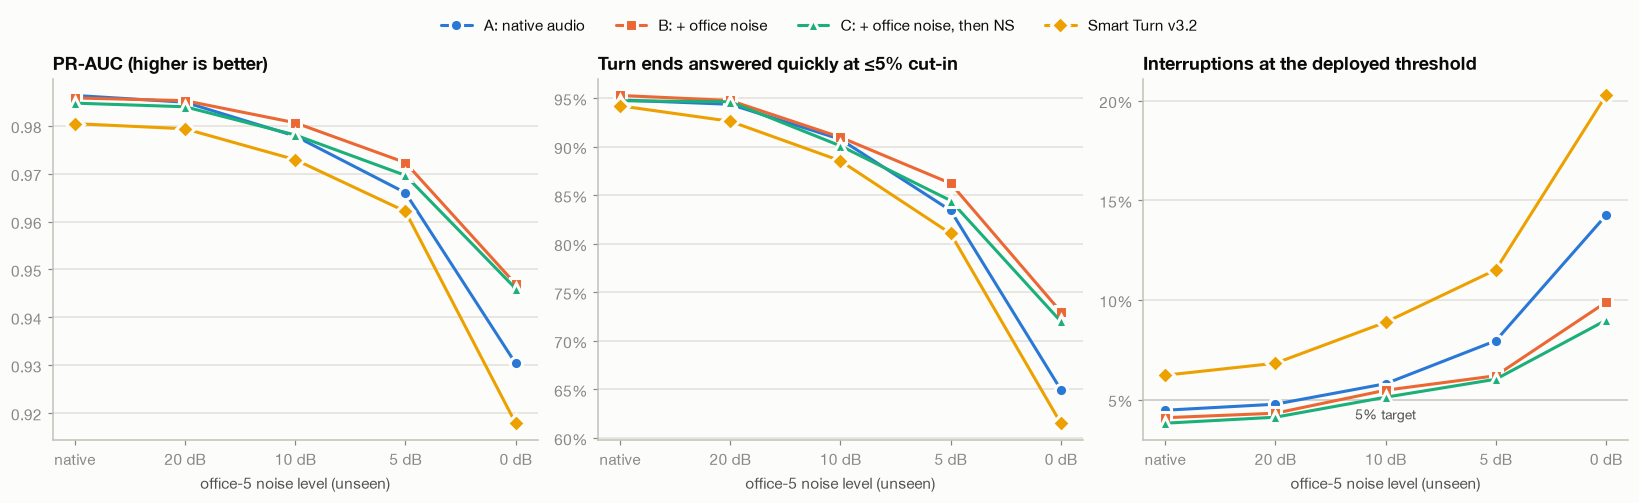

,PR-AUC native,PR-AUC 20 dB,PR-AUC 10 dB,PR-AUC 5 dB,PR-AUC 0 dB,"recall @≤5% cut-in, 0 dB","cut-in at val threshold, 0 dB"
A: native audio,0.986,0.985,0.978,0.966,0.930,0.650,0.142
B: + office noise,0.986,0.985,0.981,0.972,0.947,0.730,0.099
"C: + office noise, then NS",0.985,0.984,0.978,0.970,0.946,0.720,0.090
Smart Turn v3.2,0.980,0.979,0.973,0.962,0.918,0.615,0.203


**PR-AUC at 10 dB with 95% bootstrap confidence intervals:** A: native audio: 0.978 [0.974, 0.981] · B: + office noise: 0.981 [0.978, 0.984] · C: + office noise, then NS: 0.978 [0.974, 0.982] · Smart Turn v3.2: 0.973 [0.967, 0.977]

In [9]:
ev = json.load(open(ROOT / "reports" / "lora_eval.json"))
levels = ["native", "office5_20", "office5_10", "office5_5", "office5_0"]
xlabels = ["native", "20 dB", "10 dB", "5 dB", "0 dB"]
panels = [("pr_auc", "PR-AUC (higher is better)", None),
          ("recall_at_5pct_cut_in", "Turn ends answered quickly at ≤5% cut-in", PercentFormatter(1.0, decimals=0)),
          ("cut_in_at_val_thr", "Interruptions at the deployed threshold", PercentFormatter(1.0, decimals=0))]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (key, title, fmt) in zip(axes, panels):
    for m in MODELS:
        line(ax, range(5), [ev["deploy"][m][v][key] for v in levels], m, NAME[m], COLOR[m])
    ax.set_xticks(range(5), xlabels); ax.set_xlabel("office-5 noise level (unseen)"); ax.set_title(title)
    if fmt: ax.yaxis.set_major_formatter(fmt)
axes[2].yaxis.set_major_locator(MultipleLocator(0.05))
axes[2].axhline(0.05, color=MUTED, lw=1, zorder=0)
axes[2].annotate("5% target", (2, 0.05), xytext=(0, -13), textcoords="offset points", ha="center", color=INK2, fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.07))
fig.tight_layout(); plt.show()

table = pd.DataFrame({
    NAME[m]: {f"PR-AUC {xl}": ev["deploy"][m][v]["pr_auc"] for v, xl in zip(levels, xlabels)}
    | {"recall @≤5% cut-in, 0 dB": ev["deploy"][m]["office5_0"]["recall_at_5pct_cut_in"],
       "cut-in at val threshold, 0 dB": ev["deploy"][m]["office5_0"]["cut_in_at_val_thr"]}
    for m in MODELS}).T.round(3)
display(table)
ci = {NAME[m]: "{:.3f} [{:.3f}, {:.3f}]".format(ev["deploy"][m]["office5_10"]["pr_auc"], *ev["deploy"][m]["office5_10"]["pr_auc_ci"])
      for m in MODELS}
display(Markdown("**PR-AUC at 10 dB with 95% bootstrap confidence intervals:** " + " · ".join(f"{k}: {v}" for k, v in ci.items())))

**What the results say**
1. **Training on office noise (B) works, even for a noise B never heard.** B is best at every level of office-5, and its lead grows as the noise gets louder. At 10 dB its confidence interval does not overlap Smart Turn's.
2. **It costs nothing on clean audio:** B equals A on native clips (PR-AUC 0.986).
3. **Noise suppression (C) adds nothing over B.** C is within about 0.003 of B everywhere. WebRTC removes only 6–13 dB of office noise, so the extra processing step is not worth it.
4. **A matches or beats Smart Turn on English** (0.986 vs 0.980) with LoRA on generic Whisper and 22% of the data.
5. **Under heavy noise, models become over-eager:** Smart Turn's interruption rate climbs from 6% to 20% at 0 dB; B's only to 10%.

In [10]:
# Full matrix: every model on every input, raw vs noise-suppressed (PR-AUC). NS hurts models not trained on it.
cols = ["native", "office5_20", "office5_10", "office5_5", "office5_0", "office3_10"]
matrix = pd.DataFrame({NAME[m]: {c.replace("office5_", "office-5 ").replace("office3_10", "office-3 10 (seen)") + " dB raw / NS":
                                 f"{ev['matrix'][m][f'test_{c}']:.3f} / {ev['matrix'][m][f'test_{c}_ns']:.3f}" for c in cols}
                       for m in MODELS}).T
display(matrix)

,native dB raw / NS,office-5 20 dB raw / NS,office-5 10 dB raw / NS,office-5 5 dB raw / NS,office-5 0 dB raw / NS,office-3 10 (seen) dB raw / NS
A: native audio,0.986 / 0.985,0.985 / 0.983,0.978 / 0.976,0.966 / 0.964,0.930 / 0.929,0.973 / 0.974
B: + office noise,0.986 / 0.984,0.985 / 0.984,0.981 / 0.977,0.972 / 0.968,0.947 / 0.941,0.980 / 0.977
"C: + office noise, then NS",0.985 / 0.985,0.984 / 0.984,0.979 / 0.978,0.969 / 0.970,0.943 / 0.946,0.978 / 0.979
Smart Turn v3.2,0.980 / 0.980,0.979 / 0.978,0.973 / 0.971,0.962 / 0.955,0.918 / 0.914,0.970 / 0.964


## 7. Serving: from model to API

**Torch-free predictor** (`eot_lora/serving.py`): Whisper's log-mel is an STFT, a mel filterbank and a log clamp, reimplemented in ~20 lines of numpy. The served stack needs only numpy + ONNX Runtime, so the Docker image stays small and starts in about 2 s.

**Parity:** on all 7,820 office-5 10 dB test clips, the numpy features match the training feature extractor to 4e-5, and served probabilities match the evaluation within 5e-3: **1 decision in 7,820 flips**, PR-AUC identical (0.9806). (`scripts/check_parity.py`)

**The API** (`service/app.py`):

| Endpoint | |
|---|---|
| `POST /predict` | body = the caller's current turn as raw 16-bit PCM, 16 kHz mono (`application/octet-stream`) or a 16 kHz WAV (`audio/wav`); optional `?threshold=` |
| `GET /health` | model, threshold, threading config |
| `GET /docs` | interactive OpenAPI docs |

Response: `eot_probability`, `is_end_of_turn` (at the 0.774 threshold, i.e. ≤5% interruptions on validation), `audio_seconds`, and timings (`queue_ms`, `features_ms`, `model_ms`, `latency_ms`).

**Concurrency design:** one process runs up to `EOT_MAX_INFLIGHT` single-threaded ONNX inferences in parallel (ONNX Runtime releases Python's lock); a semaphore makes extra requests queue instead of fighting over cores.

In [11]:
# The same predictor the API uses, called in-process on the 20 sample clips (samples/*.wav, office-5 at 10 dB)
predictor = AudioEoTPredictor(ROOT / "runs" / "B")
rows = []
for f in sorted((ROOT / "samples").glob("*.wav")):
    audio = read_wav(f.read_bytes())
    t0 = time.perf_counter(); feats = predictor.features(audio)[None]
    t1 = time.perf_counter(); p = float(predictor.predict_features(feats)[0]); t2 = time.perf_counter()
    rows.append({"clip": f.stem, "label": f.stem.split("_")[1], "P(turn complete)": round(p, 3),
                 "decision": "END OF TURN" if p >= predictor.threshold else "keep listening",
                 "features ms": round((t1 - t0) * 1000, 2), "model ms": round((t2 - t1) * 1000, 1)})
df = pd.DataFrame(rows).set_index("clip")
df["correct"] = (df.label == "complete") == (df.decision == "END OF TURN")
display(df)
print(f"accuracy {df.correct.sum()}/{len(df)} · model p50 {df['model ms'].median():.1f} ms · features p50 {df['features ms'].median():.2f} ms")

,label,P(turn complete),decision,features ms,model ms,correct
clip,,,,,,
0046a354_mid-turn,mid-turn,0.027,keep listening,1.17,20.1,True
00b53923_mid-turn,mid-turn,0.684,keep listening,1.15,20.5,True
012e52a1_mid-turn,mid-turn,0.002,keep listening,1.06,18.5,True
02fd4bef_mid-turn,mid-turn,0.003,keep listening,0.89,18.5,True
04498a12_mid-turn,mid-turn,0.008,keep listening,0.91,18.5,True
04f31259_complete,complete,0.996,END OF TURN,0.90,18.9,True
07c70080_complete,complete,0.802,END OF TURN,0.88,18.7,True
07c85f8b_complete,complete,0.994,END OF TURN,0.90,18.5,True
08ab2221_mid-turn,mid-turn,0.012,keep listening,0.88,18.5,True


accuracy 19/20 · model p50 18.6 ms · features p50 0.90 ms


## 8. Live API tests

Everything below calls the running server over HTTP (start it as shown in section 1).

### 8.1 A single request

In [12]:
assert api_up(API), f"Start the API first: EOT_MAX_INFLIGHT=8 .venv/bin/uvicorn service.app:app --port 8000"
wav_path = ROOT / "samples" / "07c85f8b_complete.wav"
r = httpx.post(f"{API}/predict", content=wav_path.read_bytes(), headers={"content-type": "audio/wav"})
print("HTTP", r.status_code)
print(json.dumps(r.json(), indent=2))
display(Audio(filename=str(wav_path)))

HTTP 200
{
  "eot_probability": 0.9944695234298706,
  "is_end_of_turn": true,
  "threshold": 0.7735762000083924,
  "audio_seconds": 3.48925,
  "queue_ms": 0.009666997357271612,
  "features_ms": 5.043709003075492,
  "model_ms": 29.775999995763414,
  "latency_ms": 34.819708998838905
}


### 8.2 Raw PCM and the threshold override

A voice pipeline would send raw PCM straight from its audio buffer. `?threshold=` changes how sure the model must be; the probability itself does not change. The clip below is a borderline mid-turn pause.

In [13]:
with wave.open(str(ROOT / "samples" / "00b53923_mid-turn.wav")) as w:
    pcm = w.readframes(w.getnframes())   # raw 16-bit PCM, as a voice pipeline would send it
for thr in (None, 0.9, 0.5):
    url = f"{API}/predict" + (f"?threshold={thr}" if thr is not None else "")
    d = httpx.post(url, content=pcm, headers={"content-type": "application/octet-stream"}).json()
    print(f"threshold {d['threshold']:.3f}: P(turn complete) = {d['eot_probability']:.4f} -> "
          f"{'END OF TURN' if d['is_end_of_turn'] else 'keep listening'}")

threshold 0.774: P(turn complete) = 0.6839 -> keep listening
threshold 0.900: P(turn complete) = 0.6839 -> keep listening
threshold 0.500: P(turn complete) = 0.6839 -> END OF TURN


### 8.3 Input validation

In [14]:
def wav_bytes(rate, seconds=1.0):
    buf = io.BytesIO()
    with wave.open(buf, "wb") as w:
        w.setnchannels(1); w.setsampwidth(2); w.setframerate(rate)
        w.writeframes(np.zeros(int(rate * seconds), np.int16).tobytes())
    return buf.getvalue()

cases = [
    ("valid WAV",                  wav_path.read_bytes(),                 "audio/wav",                200),
    ("valid raw PCM",              pcm,                                   "application/octet-stream", 200),
    ("empty body",                 b"",                                   "application/octet-stream", 400),
    ("31 s of audio (limit 30 s)", np.zeros(31 * SR, np.int16).tobytes(), "application/octet-stream", 413),
    ("unsupported content type",   wav_path.read_bytes(),                 "text/plain",               415),
    ("8 kHz WAV",                  wav_bytes(8000),                       "audio/wav",                422),
    ("odd number of PCM bytes",    b"\x00\x01\x02",                       "application/octet-stream", 422),
    ("not a WAV file",             b"hello world!",                       "audio/wav",                422),
]
rows = []
for name, body, ctype, want in cases:
    r = httpx.post(f"{API}/predict", content=body, headers={"content-type": ctype})
    detail = f"P(end) = {r.json()['eot_probability']:.3f}" if r.status_code == 200 else r.json()["detail"]
    rows.append({"case": name, "expected": want, "got": r.status_code,
                 "result": "PASS" if r.status_code == want else "FAIL", "response": detail})
display(pd.DataFrame(rows).set_index("case"))
assert all(r["result"] == "PASS" for r in rows)

,expected,got,result,response
case,,,,
valid WAV,200,200,PASS,P(end) = 0.994
valid raw PCM,200,200,PASS,P(end) = 0.684
empty body,400,400,PASS,empty body: send 16 kHz 16-bit PCM or WAV audio
31 s of audio (limit 30 s),413,413,PASS,audio too long: max 30 s
unsupported content type,415,415,PASS,unsupported content-type 'text/plain': use aud...
8 kHz WAV,422,422,PASS,"could not read audio: WAV must be 16000 Hz, go..."
odd number of PCM bytes,422,422,PASS,could not read audio: raw PCM must be 16-bit s...
not a WAV file,422,422,PASS,could not read audio: file does not start with...


### 8.4 The API returns exactly what the model computes

In [15]:
diffs = []
for f in sorted((ROOT / "samples").glob("*.wav")):
    api_p = httpx.post(f"{API}/predict", content=f.read_bytes(), headers={"content-type": "audio/wav"}).json()["eot_probability"]
    diffs.append(abs(api_p - predictor.predict(read_wav(f.read_bytes()))))
print(f"20 samples: max |API - in-process| probability difference = {max(diffs):.2e}")

20 samples: max |API - in-process| probability difference = 0.00e+00


### 8.5 Accuracy through the API

300 labelled test clips with the unseen office-5 noise at 10 dB, sent one by one. The offline evaluation of model B on all 7,820 such clips gave recall 92.0% and a 5.5% cut-in rate at this threshold; with 300 clips, expect a few points of sampling noise around those numbers.

In [16]:
test_clips = load_clips("test_office5_10", 300, seed=7, pool=768)
y, p = [], []
with httpx.Client(base_url=API, timeout=30) as c:
    for clip in test_clips:
        d = c.post("/predict", content=clip["pcm"], headers={"content-type": "application/octet-stream"}).json()
        y.append(bool(clip["endpoint_bool"])); p.append(d["is_end_of_turn"])
y, p = np.array(y), np.array(p)
confusion = pd.DataFrame([[int((y & p).sum()), int((y & ~p).sum())], [int((~y & p).sum()), int((~y & ~p).sum())]],
                         index=["actually complete", "actually mid-turn"], columns=["API: END OF TURN", "API: keep listening"])
display(confusion)
print(f"accuracy {100 * (y == p).mean():.1f}% · recall (turn ends answered quickly) {100 * (y & p).sum() / y.sum():.1f}% · "
      f"cut-in (interruptions) {100 * (~y & p).sum() / (~y).sum():.1f}%")

,API: END OF TURN,API: keep listening
actually complete,125,15
actually mid-turn,11,149


accuracy 91.3% · recall (turn ends answered quickly) 89.3% · cut-in (interruptions) 6.9%


### 8.6 Latency and concurrency

A small in-notebook load test: 200 requests at 1, 4 and 8 concurrent clients. The full benchmark (section 9) uses `scripts/run_stress_grid.sh`.

In [17]:
payloads = [c["pcm"] for c in test_clips[:100]]

async def burst(url, clients, total):
    latency, jobs = [], iter(range(total))
    async with httpx.AsyncClient(base_url=url, timeout=60, limits=httpx.Limits(max_connections=clients)) as c:
        async def worker():
            for i in jobs:
                t0 = time.perf_counter()
                r = await c.post("/predict", content=payloads[i % len(payloads)], headers={"content-type": "application/octet-stream"})
                r.raise_for_status(); latency.append((time.perf_counter() - t0) * 1000)
        t0 = time.perf_counter(); await asyncio.gather(*(worker() for _ in range(clients))); elapsed = time.perf_counter() - t0
    return {"clients": clients, "requests": total, "throughput (req/s)": round(total / elapsed, 1),
            "p50 ms": round(np.percentile(latency, 50), 1), "p95 ms": round(np.percentile(latency, 95), 1),
            "p99 ms": round(np.percentile(latency, 99), 1)}

results = [await burst(API, n, 200) for n in (1, 4, 8)]
display(pd.DataFrame(results).set_index("clients"))

,requests,throughput (req/s),p50 ms,p95 ms,p99 ms
clients,,,,,
1,200,47.8,20.7,21.3,25.5
4,200,124.8,32.0,34.8,41.2
8,200,160.9,48.7,60.8,66.2


### 8.7 The same API in Docker

The image (`Dockerfile`: `python:3.12-slim` + fastapi, uvicorn, numpy, onnxruntime; 511 MB) gives identical answers. On this Mac it is about 3.5× slower, because Docker Desktop runs containers in a Linux VM that cannot use the M5's SME matrix instructions. On a Linux server there is no VM in the way.

In [18]:
if api_up(DOCKER_API):
    rows = []
    for f in sorted((ROOT / "samples").glob("*.wav"))[:10]:
        body = f.read_bytes()
        a = httpx.post(f"{API}/predict", content=body, headers={"content-type": "audio/wav"}).json()
        b = httpx.post(f"{DOCKER_API}/predict", content=body, headers={"content-type": "audio/wav"}).json()
        rows.append({"clip": f.stem, "P bare metal": round(a["eot_probability"], 4), "P Docker": round(b["eot_probability"], 4),
                     "server ms, bare metal": round(a["latency_ms"], 1), "server ms, Docker": round(b["latency_ms"], 1)})
    df = pd.DataFrame(rows).set_index("clip")
    display(df)
    print(f"max probability difference: {(df['P bare metal'] - df['P Docker']).abs().max():.4f}")
else:
    print("Docker container not running. Start it with:\n"
          "  docker run --rm -d -p 8001:8000 --cpus 4 -e EOT_MAX_INFLIGHT=4 eot-audio")

,P bare metal,P Docker,"server ms, bare metal","server ms, Docker"
clip,,,,
0046a354_mid-turn,0.0268,0.0268,20.0,127.9
00b53923_mid-turn,0.6839,0.6839,22.2,72.3
012e52a1_mid-turn,0.0017,0.0017,24.6,73.3
02fd4bef_mid-turn,0.0034,0.0034,25.3,72.9
04498a12_mid-turn,0.0084,0.0084,24.7,73.2
04f31259_complete,0.9960,0.9960,24.1,72.9
07c70080_complete,0.8023,0.8023,24.5,72.8
07c85f8b_complete,0.9945,0.9945,24.5,73.1
08ab2221_mid-turn,0.0120,0.0120,24.8,73.8


max probability difference: 0.0000


## 9. Load testing (full benchmark)

`bash scripts/run_stress_grid.sh` starts a fresh server per configuration and runs `scripts/stress_test.py` against it with 500 real test clips (8 s each, 256 KB per request). Machine: Apple M5 laptop, 10 cores (4 performance + 6 efficiency); the load generator runs on the same machine.

- **Closed loop:** C clients each send their next request as soon as the previous one returns. Finds peak throughput.
- **Open loop:** requests arrive at a fixed average rate, whether or not the server keeps up, like independent phone calls. Finds the rate the server can sustain under a latency target (p99 < 100 ms).

In [19]:
display(Markdown(open(ROOT / "reports" / "bench_model.md").read().replace("# Model benchmark (no HTTP)", "#### Model only, without HTTP")))

#### Model only, without HTTP

- Machine: Darwin arm64, Apple M5, 10 cores
- Cold start: session load 15 ms, first prediction 22 ms; peak RSS of this process 754 MB

## Per-stage latency, 1 thread, batch 1 (200 clips)

| Stage | p50 (ms) | p95 (ms) |
|---|---:|---:|
| Decode PCM | 0.04 | 0.04 |
| Log-mel (numpy) | 0.82 | 0.84 |
| Model (ONNX fp32) | 18.96 | 19.60 |

## ONNX threads per inference (batch 1)

| Threads | Model p50 (ms) |
|---:|---:|
| 1 | 19.04 |
| 2 | 12.74 |
| 4 | 9.85 |

## Batch size (1 thread)

| Batch | ms per batch | ms per clip |
|---:|---:|---:|
| 1 | 19.3 | 19.3 |
| 2 | 38.0 | 19.0 |
| 4 | 77.4 | 19.3 |
| 8 | 158.5 | 19.8 |
| 16 | 323.7 | 20.2 |

## fp32 vs int8 (dynamic quantization)

| Variant | Size (MB) | Model p50 (ms) | PR-AUC (1,000 clips) |
|---|---:|---:|---:|
| fp32 | 32.4 | 18.96 | 0.9837 |
| int8 dynamic | 8.4 | 19.98 | 0.9819 |

Max |fp32 - int8| probability difference: 0.416


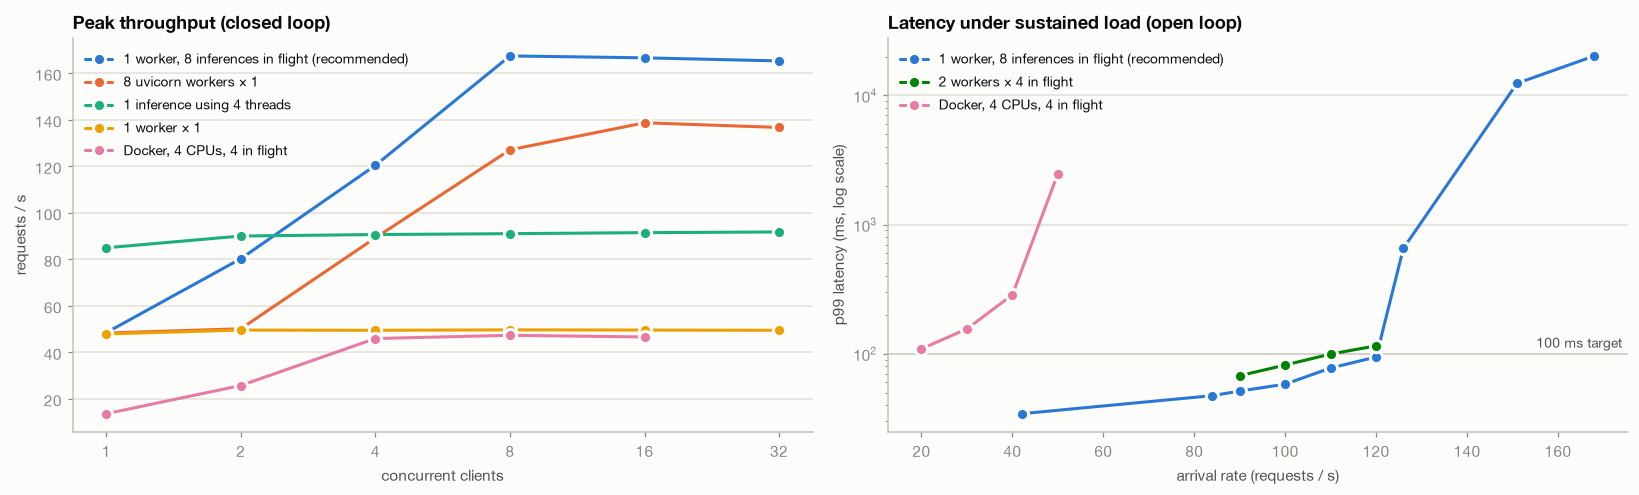

,peak req/s,at clients,p50 ms,p99 ms,model ms (p50)
"1 worker, 8 inferences in flight (recommended)",167.5,8,47.6,58.4,42.5
8 uvicorn workers × 1,138.8,16,70.5,290.6,32.3
1 inference using 4 threads,90.1,2,22.1,24.1,9.9
1 worker × 1,48.0,1,20.8,21.4,18.9
"Docker, 4 CPUs, 4 in flight",46.0,4,85.7,119.4,79.4
2 workers × 4 in flight,161.6,16,126.1,160.5,38.8


**Open loop, 1 worker × 8 in flight:**

,served req/s,p50 ms,p95 ms,p99 ms
offered_rps,,,,
42.0,40.9,23.1,31.0,34.3
84.0,82.5,26.8,39.3,47.4
90.0,88.3,27.4,42.3,51.4
100.0,98.2,29.1,47.2,58.1
110.0,108.3,33.4,59.9,77.5
120.0,117.4,38.8,75.9,94.3
126.0,122.6,37.7,216.4,655.0
151.0,125.7,1121.0,8054.0,12401.9
168.0,127.5,2093.4,15520.8,20205.0


In [20]:
rows = [json.loads(l) for l in open(ROOT / "reports" / "stress_results.jsonl")]
closed = pd.DataFrame([r for r in rows if r["mode"] == "closed"])
configs = {"w1i8": "1 worker, 8 inferences in flight (recommended)", "w8": "8 uvicorn workers × 1",
           "w1t4": "1 inference using 4 threads", "w1": "1 worker × 1", "docker_c4": "Docker, 4 CPUs, 4 in flight",
           "w2i4": "2 workers × 4 in flight"}
ccolor = {"w1i8": "#2a78d6", "w8": "#eb6834", "w1t4": "#1baf7a", "w1": "#eda100", "docker_c4": "#e87ba4", "w2i4": "#008300"}

open_ = pd.DataFrame([r for r in rows if r["mode"] == "open"])
open_["config"] = open_.tag.str.replace(r"_open(_knee)?$", "", regex=True)
open_ = open_.sort_values(["config", "offered_rps"]).drop_duplicates(["config", "offered_rps"], keep="last")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for tag in ["w1i8", "w8", "w1t4", "w1", "docker_c4"]:
    d = closed[closed.tag == tag].sort_values("concurrency")
    line(axes[0], d.concurrency, d.rps, "o", configs[tag], ccolor[tag])
axes[0].set_xscale("log", base=2); axes[0].set_xticks([1, 2, 4, 8, 16, 32], ["1", "2", "4", "8", "16", "32"])
axes[0].set_xlabel("concurrent clients"); axes[0].set_ylabel("requests / s"); axes[0].set_title("Peak throughput (closed loop)")
axes[0].legend(loc="upper left", fontsize=9)

for tag in ["w1i8", "w2i4", "docker_c4"]:
    d = open_[open_.config == tag]
    line(axes[1], d.offered_rps, d.p99, "o", configs[tag], ccolor[tag])
axes[1].set_yscale("log"); axes[1].axhline(100, color=MUTED, lw=1, zorder=0)
axes[1].annotate("100 ms target", (axes[1].get_xlim()[1], 100), xytext=(-4, 4), textcoords="offset points", ha="right",
                 color=INK2, fontsize=9)
axes[1].set_xlabel("arrival rate (requests / s)"); axes[1].set_ylabel("p99 latency (ms, log scale)")
axes[1].set_title("Latency under sustained load (open loop)"); axes[1].legend(loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()

# Report each config where it first reaches 95% of its peak (beyond that, more clients only add queueing)
first_at_peak = [d[d.rps >= 0.95 * d.rps.max()].iloc[0] for _, d in closed.sort_values("concurrency").groupby("tag")]
peak = (pd.DataFrame(first_at_peak).set_index("tag")
        .loc[[t for t in configs if t in set(closed.tag)], ["rps", "concurrency", "p50", "p99", "model_p50"]].round(1))
peak.index = [configs[t] for t in peak.index]
peak.columns = ["peak req/s", "at clients", "p50 ms", "p99 ms", "model ms (p50)"]
display(peak)
knee = open_[open_.config == "w1i8"][["offered_rps", "rps", "p50", "p95", "p99"]].round(1).set_index("offered_rps")
knee.columns = ["served req/s", "p50 ms", "p95 ms", "p99 ms"]
display(Markdown("**Open loop, 1 worker × 8 in flight:**")); display(knee)

**What the load tests say**
- **The model is ~95% of the time.** 19 ms of the 20.8 ms per request; HTTP, the 256 KB body and the log-mel add about 1 ms.
- **Capacity: about 120 requests/s with p99 under 100 ms** (1 process, 8 inferences in flight, ~470 MB). Past that the server saturates abruptly, so plan for ~100 req/s per machine. That covers the ~60 req/s peak estimated for 1M calls/month with 2× headroom.
- **How the server runs matters more than the hardware:** 8 uvicorn workers reached only 139 req/s with p99 around 300 ms, because uvicorn balances connections, not individual requests. One process with 8 inference slots balances every request.
- **fp32, no batching:** dynamic int8 was slower (20.0 ms) and less accurate; batching gave no speed-up per clip on CPU.

## 10. Conclusions and next steps

**Conclusions**
1. **Train with the noise you expect.** Model B, trained with one office recording, stays reliable on a different office recording: at 0 dB it answers 73% of turn ends quickly vs Smart Turn's 62%, with half the interruptions, and loses nothing on clean audio.
2. **Skip WebRTC noise suppression** for this model: it removes only 6–13 dB of office noise and gives no gain over noise-aware training.
3. **LoRA is enough.** Training 7.6% of the weights on 59k English clips matches or beats Smart Turn's full fine-tune on English.
4. **Serving is cheap:** a 32 MB ONNX model, ~21 ms per request on a laptop CPU, ~120 req/s under a 100 ms p99, in a 511 MB Docker image.

**Caveats:** a third of the speech is synthetic and all of it is 16 kHz (8 kHz phone audio untested); two office recordings; one training run (one seed) per model; measured on a laptop.

**Next steps**
- Start from Smart Turn's trained weights and add the office-noise LoRA on top.
- Test on real phone-call audio with more noise types (street, car, call-centre babble) and 8 kHz telephony.
- A streaming WebSocket API (send audio frames once, not 8 s per check), or run the model in-process in the voice orchestrator.
- Fuse with the text model from the first project (`~/Desktop/happyrobot`): audio for tone, text for dialogue context.

## Credits

- **Pipecat Smart Turn:** [github.com/pipecat-ai/smart-turn](https://github.com/pipecat-ai/smart-turn), BSD 2-Clause, © 2024–2025 Daily. Contributors: Marcus, Eli, Mark and Kwindla. We use:
  - the baseline model ([Smart Turn v3.2](https://huggingface.co/pipecat-ai/smart-turn-v3));
  - the design of our model head, 8 s window and loss;
  - the training and test data ([smart-turn-data-v3.2](https://huggingface.co/datasets/pipecat-ai/smart-turn-data-v3.2-train); no license declared on the dataset card). The dataset credits the Pipecat team, Liva AI, Midcentury, MundoAI, and 40 Freesound contributors of CC0 background noise.
- **Office noise:** "IT office 3" and "IT office 5" by **thellywellyn** on Pixabay (Pixabay Content License).
- **Whisper:** OpenAI, Radford et al. 2022 (`openai/whisper-tiny`).
- **LoRA:** Hu et al. 2021, via Hugging Face PEFT.
- **Libraries:** Hugging Face Transformers, PyTorch, ONNX Runtime, LiveKit (WebRTC audio processing), PyAV, FastAPI and others.
- **Built with the help of** Claude Code (Anthropic).

Full list with licenses: `CREDITS.md`.